In [1]:
#this file creates a plot using fitting function.
# this will also use create a file with asymptote

C:\Users\Student\AppData\Local\Temp\ipykernel_16676\1574693274.py:42: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


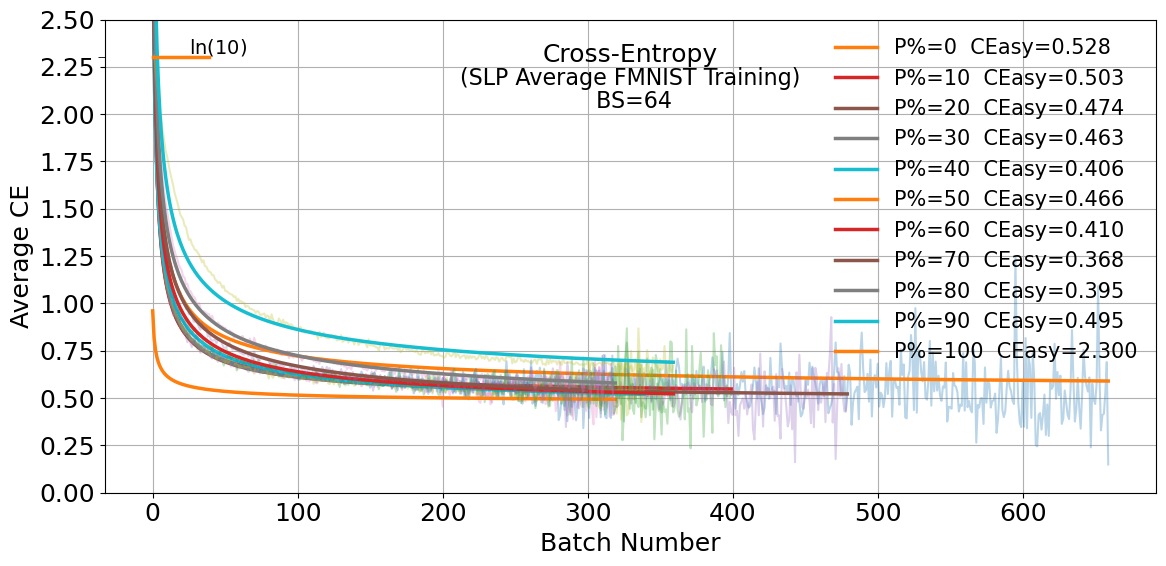

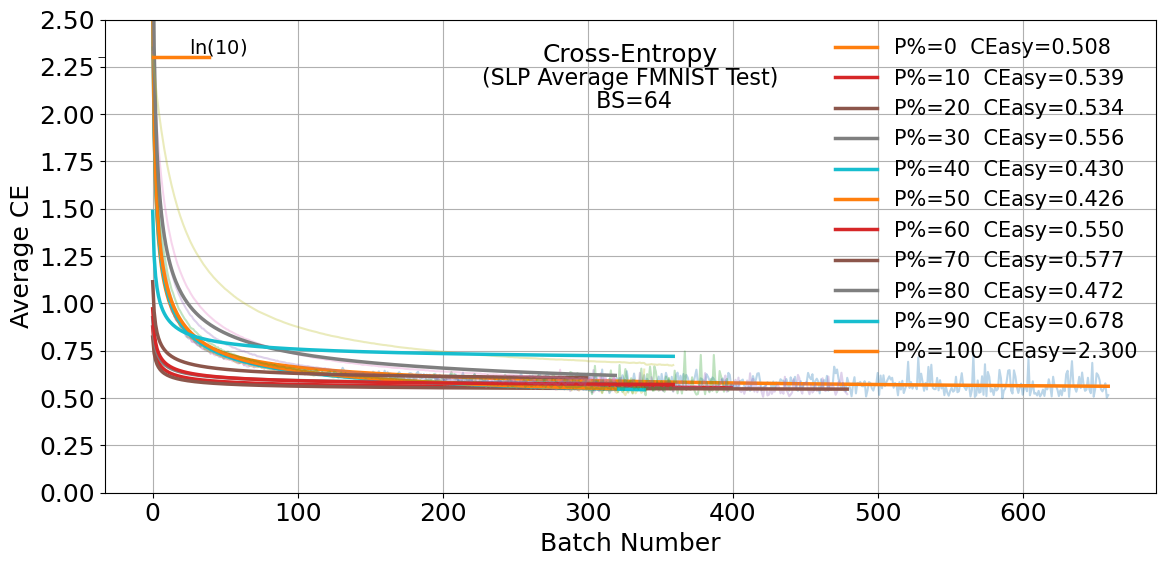

C:\Users\Student\AppData\Local\Temp\ipykernel_16676\1574693274.py:42: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


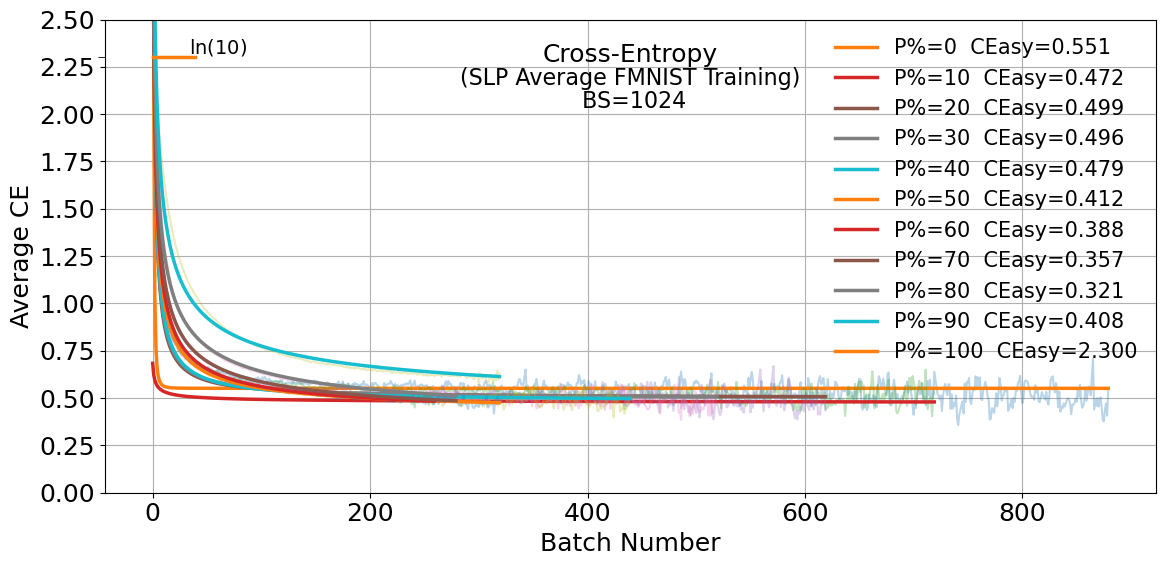

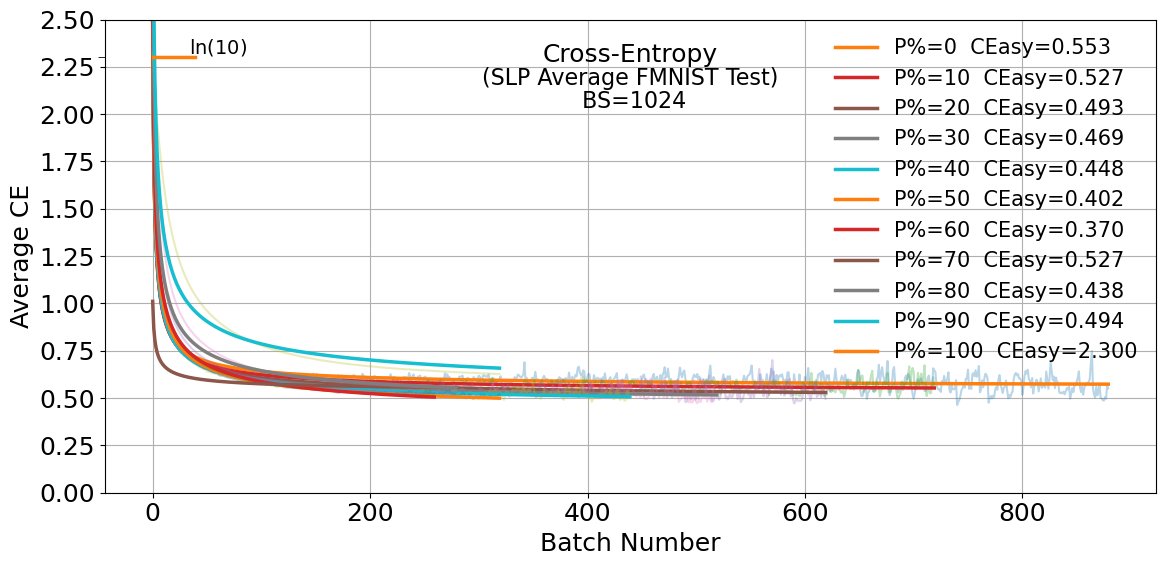

C:\Users\Student\AppData\Local\Temp\ipykernel_16676\1574693274.py:42: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


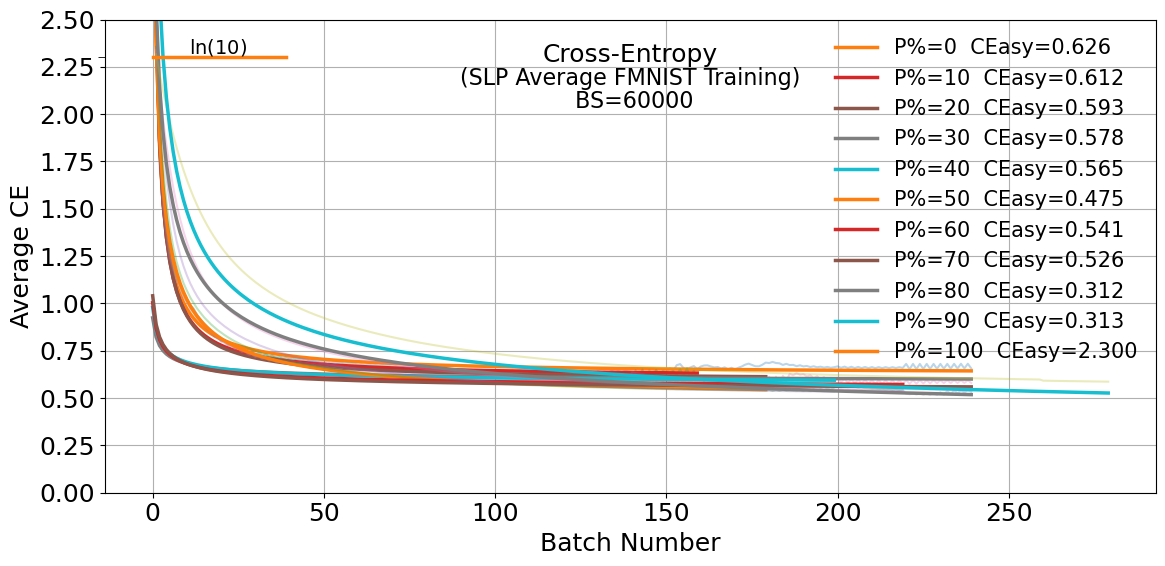

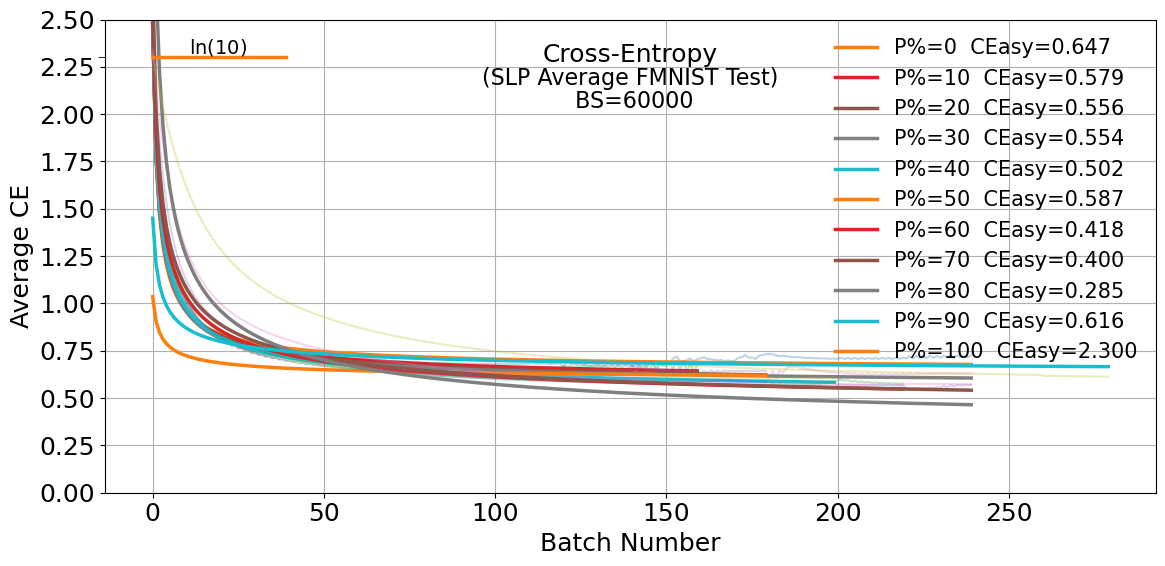

In [18]:
#ChatGPT implementing fitting function of 2nd code block into plotting of the 1st block
# weight value wsa changed to 1 instead of squaring based on the data
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"


BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN = "slp_{:.1f}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]

LN10 = np.log(10)

# =========================
# FIT PARAMETERS
# =========================
A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0

# =========================
# FITTING FUNCTIONS
# =========================
def initialize_guesses(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5

    if len(x) > 10:
        frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
        if frac > 0:
            n0 = max(0.3, min(1.5, -np.log(frac)))

    return A0, n0, B0

def model(params, x):
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)

def residual(params, x, data):
    # weight = x
    # return weight * (model(params, x) - data)
    return (model(params, x) - data)
    
    

def fit_curve(x, y):
    mask = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 10:
        return None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)

    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        out = minimize(residual, params, args=(x_fit, y_fit))
        return out
    except:
        return None

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15
})

# =========================
# MAIN LOOP
# =========================
for bs in BATCH_SIZES:

    all_avg_dfs = {}

    # -------------------------
    # LOAD + AVERAGE
    # -------------------------
    for p in [round(x * 0.1, 1) for x in range(0, 11)]:

        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
            continue

        dfs = []
        for f in files:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()

            df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
            df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
            df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

            dfs.append(df)

        all_runs = pd.concat(dfs, ignore_index=True)

        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
        avg_df.to_csv(out_csv, index=False)

        all_avg_dfs[p] = avg_df

    # -------------------------
    # CE TRAIN PLOT + FIT
    # -------------------------
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():

        x = avg_df["Batch_Number"].to_numpy(dtype=float)
        y = avg_df["Avg_CE_Train"].to_numpy(dtype=float)

        plt.plot(x, y, alpha=0.3)

        fit = fit_curve(x, y)

        if fit is not None:
            y_fit = model(fit.params, x)
            A_val = fit.params['A'].value

            plt.plot(
                x, y_fit,
                linewidth=2.5,
                label=f"P%={int(p*100)}  CEasy={A_val:.3f}"
            )
        else:
            plt.plot(x, y, label=f"P%={int(p*100)}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")

    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)

    plt.text(0.50, 0.95, "Cross-Entropy",
             transform=plt.gca().transAxes, va="top", ha="center")

    plt.text(0.50, 0.90,
             f"(SLP Average FMNIST Training)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85,f" BS={bs}",
         transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(
    frameon=False,
    loc='upper right'  # or 'upper right', 'lower right'
    )
    plt.grid(True)
    plt.tight_layout()



    plt.savefig(f"CE_Train_Fit_BS_{bs}.png", dpi=300)
    plt.show()

    # -------------------------
    # CE TEST PLOT + FIT
    # -------------------------
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():

        x = avg_df["Batch_Number"].to_numpy(dtype=float)
        y = avg_df["Avg_CE_Test"].to_numpy(dtype=float)

        plt.plot(x, y, alpha=0.3)

        fit = fit_curve(x, y)

        if fit is not None:
            y_fit = model(fit.params, x)
            A_val = fit.params['A'].value

            plt.plot(
                x, y_fit,
                linewidth=2.5,
                label=f"P%={int(p*100)}  CEasy={A_val:.3f}"
            )
        else:
            plt.plot(x, y, label=f"P%={int(p*100)}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")
    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)


    plt.text(0.50, 0.95, "Cross-Entropy",
             transform=plt.gca().transAxes, va="top", ha="center")

    plt.text(0.50, 0.90,
             f"(SLP Average FMNIST Test)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85,f" BS={bs}",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)


    plt.legend(
    frameon=False,
    loc='upper right'  # or 'upper right', 'lower right'
    )
    plt.grid(True)
    plt.tight_layout()



    plt.savefig(f"CE_Test_Fit_BS_{bs}.png", dpi=300)
    plt.show()

C:\Users\Student\AppData\Local\Temp\ipykernel_16676\3345867525.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


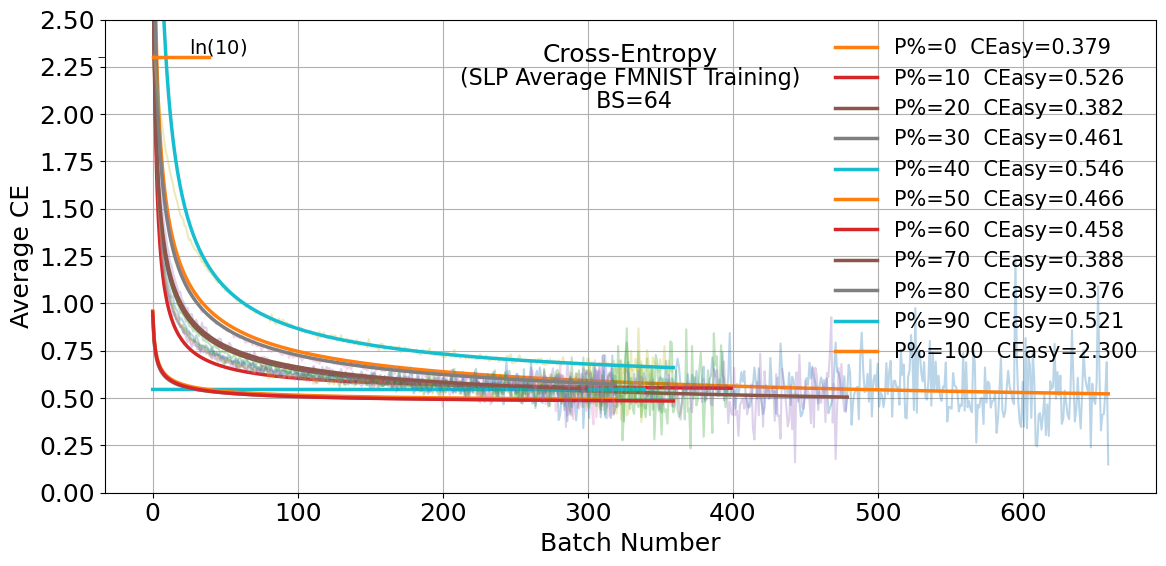

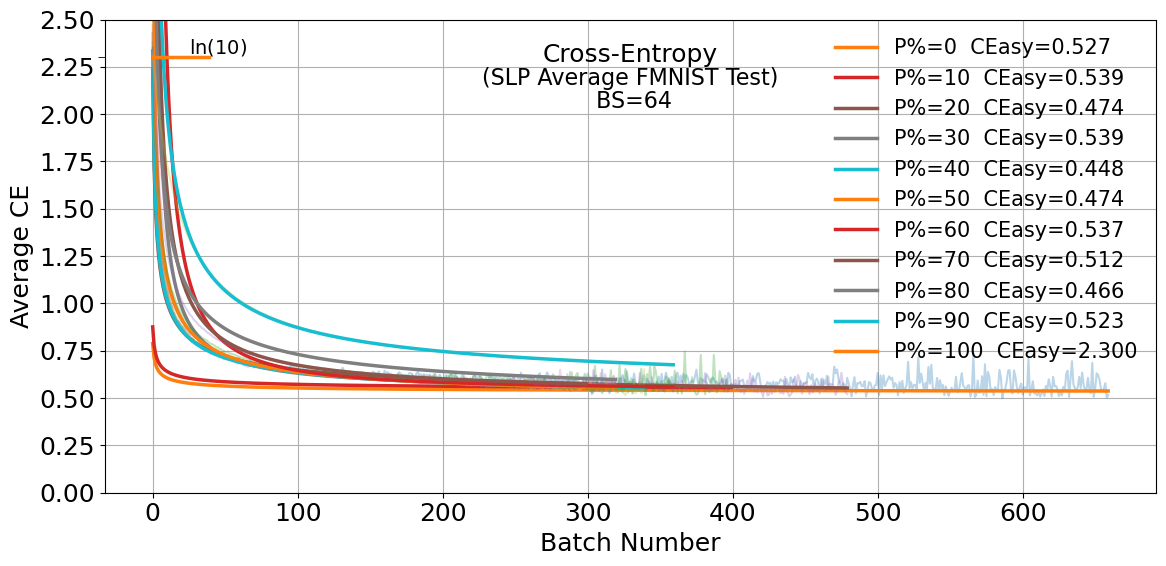

[DONE] Asymptotes saved for Batch Size 64


C:\Users\Student\AppData\Local\Temp\ipykernel_16676\3345867525.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


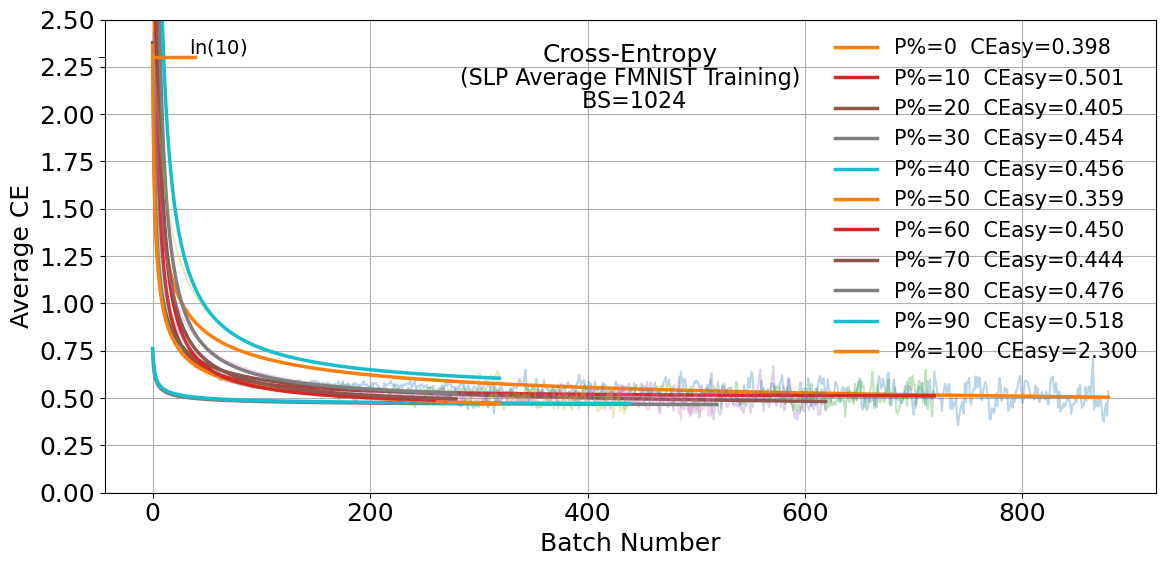

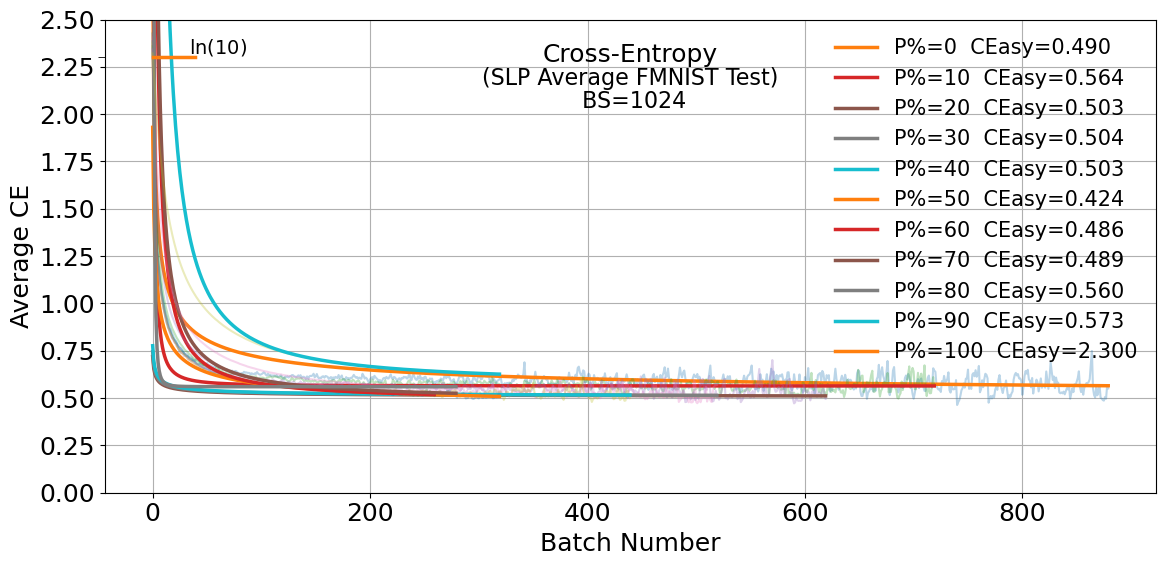

[DONE] Asymptotes saved for Batch Size 1024


C:\Users\Student\AppData\Local\Temp\ipykernel_16676\3345867525.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


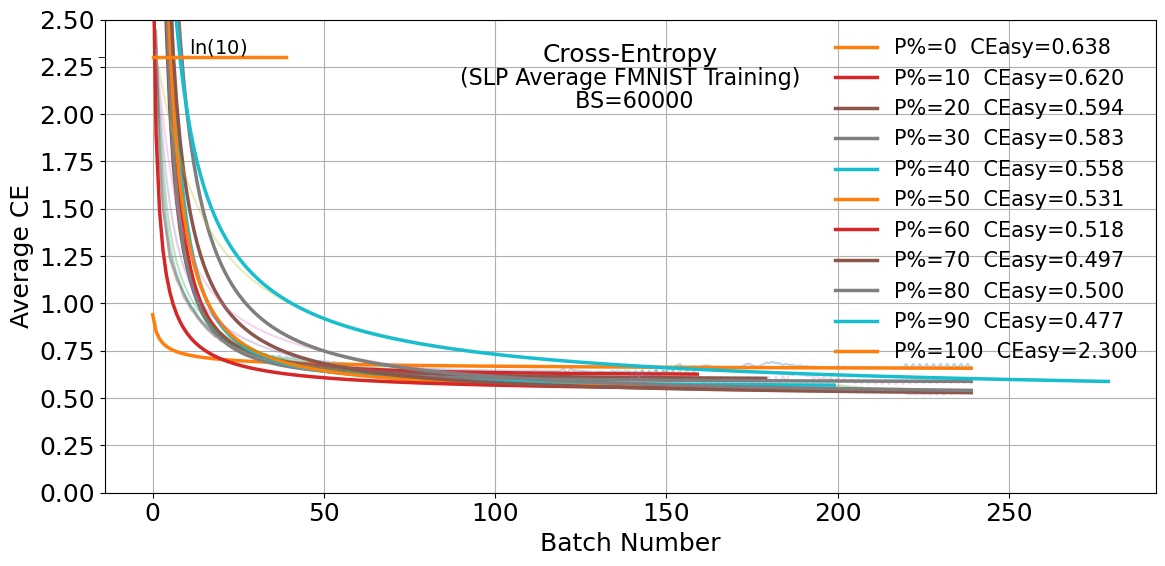

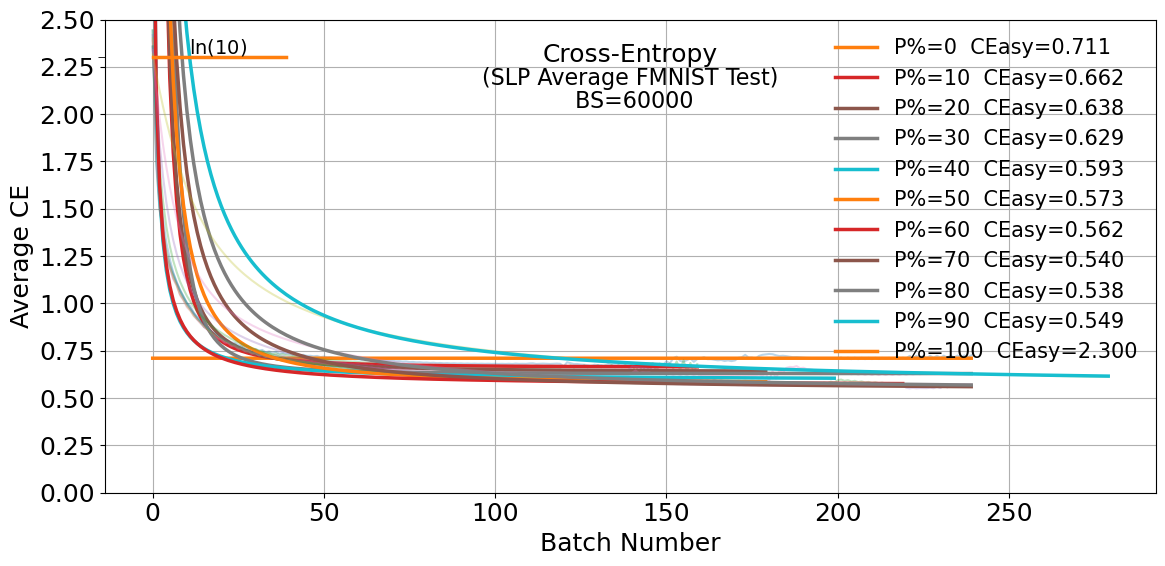

[DONE] Asymptotes saved for Batch Size 60000


In [13]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"

BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN = "slp_{:.1f}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]

LN10 = np.log(10)

# =========================
# FIT PARAMETERS
# =========================
A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0

# =========================
# FITTING FUNCTIONS
# =========================
def initialize_guesses(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5

    if len(x) > 10:
        frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
        if frac > 0:
            n0 = max(0.3, min(1.5, -np.log(frac)))

    return A0, n0, B0

def model(params, x):
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)

def residual(params, x, data):
    weight = x**2
    return weight * (model(params, x) - data)

def fit_curve(x, y):
    mask = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 10:
        return None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)

    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        out = minimize(residual, params, args=(x_fit, y_fit))
        return out
    except:
        return None

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15
})

# =========================
# MAIN LOOP
# =========================
os.makedirs("Asymptote_Data", exist_ok=True)

for bs in BATCH_SIZES:

    all_avg_dfs = {}

    # -------------------------
    # LOAD + AVERAGE
    # -------------------------
    for p in [round(x * 0.1, 1) for x in range(0, 11)]:

        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
            continue

        dfs = []
        for f in files:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()

            df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
            df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
            df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

            dfs.append(df)

        all_runs = pd.concat(dfs, ignore_index=True)

        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
        avg_df.to_csv(out_csv, index=False)

        all_avg_dfs[p] = avg_df

    # -------------------------
    # CE TRAIN PLOT + FIT
    # -------------------------
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():

        x = avg_df["Batch_Number"].to_numpy(dtype=float)
        y = avg_df["Avg_CE_Train"].to_numpy(dtype=float)

        plt.plot(x, y, alpha=0.3)

        fit = fit_curve(x, y)

        if fit is not None:
            y_fit = model(fit.params, x)
            A_val = fit.params['A'].value

            plt.plot(
                x, y_fit,
                linewidth=2.5,
                label=f"P%={int(p*100)}  CEasy={A_val:.3f}"
            )
        else:
            plt.plot(x, y, label=f"P%={int(p*100)}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")

    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)

    plt.text(0.50, 0.95, "Cross-Entropy",
             transform=plt.gca().transAxes, va="top", ha="center")

    plt.text(0.50, 0.90,
             f"(SLP Average FMNIST Training)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85,f" BS={bs}",
         transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(frameon=False, loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"CE_Train_Fit_BS_{bs}.png", dpi=300)
    plt.show()

    # -------------------------
    # CE TEST PLOT + FIT
    # -------------------------
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():

        x = avg_df["Batch_Number"].to_numpy(dtype=float)
        y = avg_df["Avg_CE_Test"].to_numpy(dtype=float)

        plt.plot(x, y, alpha=0.3)

        fit = fit_curve(x, y)

        if fit is not None:
            y_fit = model(fit.params, x)
            A_val = fit.params['A'].value

            plt.plot(
                x, y_fit,
                linewidth=2.5,
                label=f"P%={int(p*100)}  CEasy={A_val:.3f}"
            )
        else:
            plt.plot(x, y, label=f"P%={int(p*100)}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")
    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)

    plt.text(0.50, 0.95, "Cross-Entropy",
             transform=plt.gca().transAxes, va="top", ha="center")

    plt.text(0.50, 0.90,
             f"(SLP Average FMNIST Test)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85,f" BS={bs}",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(frameon=False, loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"CE_Test_Fit_BS_{bs}.png", dpi=300)
    plt.show()

    # -------------------------
    # SAVE ASYMPTOTES
    # -------------------------
    asymptote_rows = []
    for p, avg_df in all_avg_dfs.items():
        # Train
        x_train = avg_df["Batch_Number"].to_numpy(dtype=float)
        y_train = avg_df["Avg_CE_Train"].to_numpy(dtype=float)
        fit_train = fit_curve(x_train, y_train)
        A_train = fit_train.params['A'].value if fit_train is not None else np.nan

        # Test
        x_test = avg_df["Batch_Number"].to_numpy(dtype=float)
        y_test = avg_df["Avg_CE_Test"].to_numpy(dtype=float)
        fit_test = fit_curve(x_test, y_test)
        A_test = fit_test.params['A'].value if fit_test is not None else np.nan

        asymptote_rows.append([int(p*100), bs, A_train, A_test])

    df_asymptotes = pd.DataFrame(asymptote_rows, columns=[
        "Pruning_Percentage", "Batch_Size", "CE_Train_Asymptote", "CE_Test_Asymptote"
    ])

    df_asymptotes.to_csv(f"Asymptote_Data/CE_Asymptotes_BS_{bs}.csv", index=False)
    print(f"[DONE] Asymptotes saved for Batch Size {bs}")


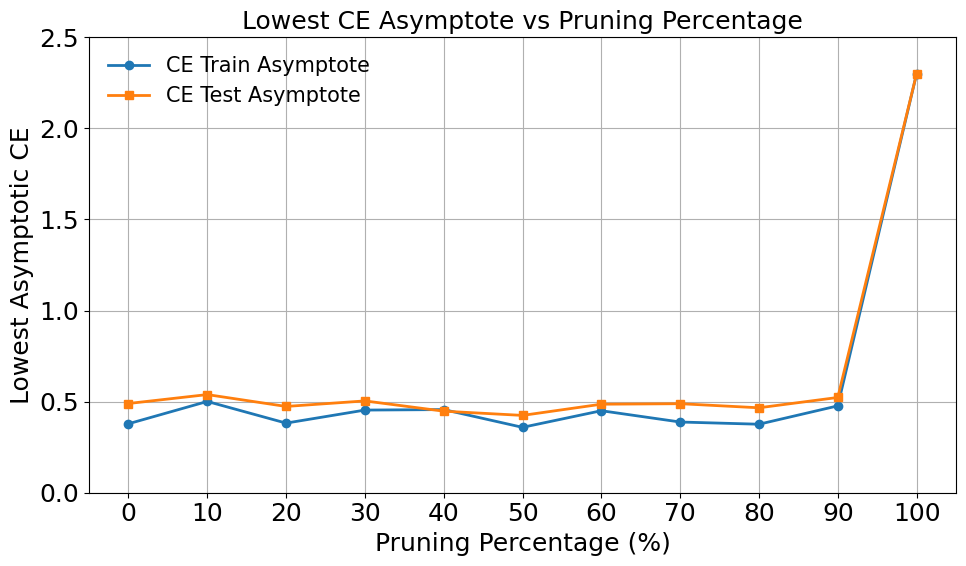

In [14]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# LOAD ALL ASYMPTOTE CSVs
# -------------------------
files = glob.glob("Asymptote_Data/CE_Asymptotes_BS_*.csv")

all_asymptotes = []

for f in files:
    df = pd.read_csv(f)
    all_asymptotes.append(df)

all_asymptotes_df = pd.concat(all_asymptotes, ignore_index=True)

# -------------------------
# FIND MINIMUM ASYMPTOTE ACROSS BATCH SIZES
# -------------------------
# For each pruning percentage, find the lowest CE_Train_Asymptote and CE_Test_Asymptote
summary_df = all_asymptotes_df.groupby("Pruning_Percentage").agg({
    "CE_Train_Asymptote": "min",
    "CE_Test_Asymptote": "min"
}).reset_index()

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(summary_df["Pruning_Percentage"], summary_df["CE_Train_Asymptote"],
         marker='o', linewidth=2, label="CE Train Asymptote")
plt.plot(summary_df["Pruning_Percentage"], summary_df["CE_Test_Asymptote"],
         marker='s', linewidth=2, label="CE Test Asymptote")

plt.xlabel("Pruning Percentage (%)")
plt.ylabel("Lowest Asymptotic CE")
plt.title("Lowest CE Asymptote vs Pruning Percentage")
plt.xticks(summary_df["Pruning_Percentage"])
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


C:\Users\Student\AppData\Local\Temp\ipykernel_16676\2515979456.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
C:\Users\Student\AppData\Local\Temp\ipykernel_16676\2515979456.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
C:\Users\Student\AppData\Local\Temp\ipykernel_16676\2515979456.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
C:\Users\Student\AppData\Local\Temp\ipykernel_16676\2515979456.py:166: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot = df_asymptotes.groupby("Pruning_Percentage").apply

[DONE] All asymptotes saved in a single file: Asymptote_Data/CE_Asymptotes_All_BatchSizes.csv


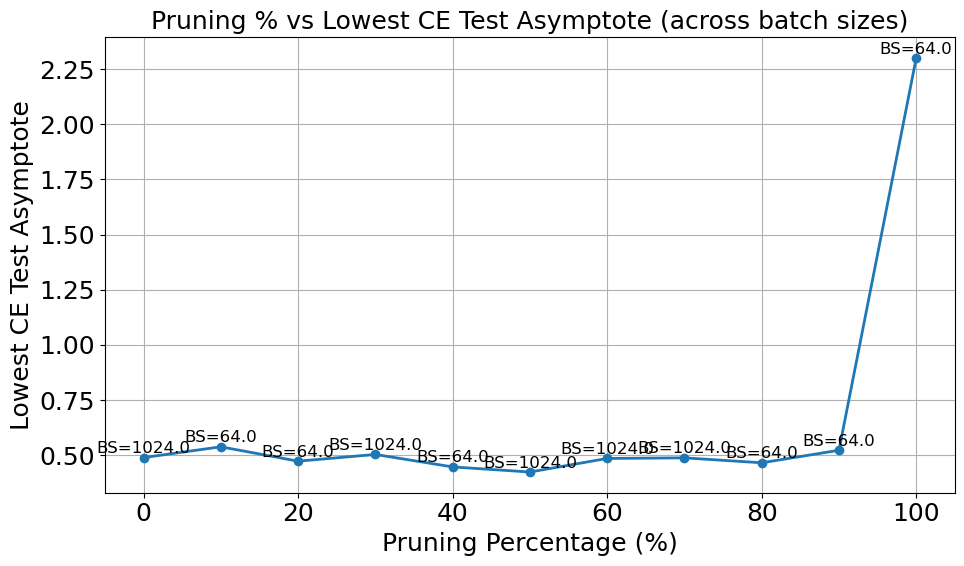

In [16]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"

BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN = "slp_{:.1f}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]

LN10 = np.log(10)

# =========================
# FIT PARAMETERS
# =========================
A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0

# =========================
# FITTING FUNCTIONS
# =========================
def initialize_guesses(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5

    if len(x) > 10:
        frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
        if frac > 0:
            n0 = max(0.3, min(1.5, -np.log(frac)))

    return A0, n0, B0

def model(params, x):
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)

def residual(params, x, data):
    weight = x**2
    return weight * (model(params, x) - data)

def fit_curve(x, y):
    mask = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 10:
        return None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)

    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        out = minimize(residual, params, args=(x_fit, y_fit))
        return out
    except:
        return None

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15
})

# =========================
# MAIN LOOP
# =========================
os.makedirs("Asymptote_Data", exist_ok=True)

all_asymptotes_rows = []  # store all batch sizes together

for bs in BATCH_SIZES:

    all_avg_dfs = {}

    # -------------------------
    # LOAD + AVERAGE
    # -------------------------
    for p in [round(x * 0.1, 1) for x in range(0, 11)]:

        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
            continue

        dfs = []
        for f in files:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()

            df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
            df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
            df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

            dfs.append(df)

        all_runs = pd.concat(dfs, ignore_index=True)

        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        all_avg_dfs[p] = avg_df

    # -------------------------
    # SAVE ASYMPTOTES
    # -------------------------
    for p, avg_df in all_avg_dfs.items():
        # Train
        x_train = avg_df["Batch_Number"].to_numpy(dtype=float)
        y_train = avg_df["Avg_CE_Train"].to_numpy(dtype=float)
        fit_train = fit_curve(x_train, y_train)
        A_train = fit_train.params['A'].value if fit_train is not None else np.nan

        # Test
        x_test = avg_df["Batch_Number"].to_numpy(dtype=float)
        y_test = avg_df["Avg_CE_Test"].to_numpy(dtype=float)
        fit_test = fit_curve(x_test, y_test)
        A_test = fit_test.params['A'].value if fit_test is not None else np.nan

        all_asymptotes_rows.append([int(p*100), bs, A_train, A_test])

# -------------------------
# SAVE SINGLE FILE
# -------------------------
df_asymptotes = pd.DataFrame(all_asymptotes_rows, columns=[
    "Pruning_Percentage", "Batch_Size", "CE_Train_Asymptote", "CE_Test_Asymptote"
])
csv_path = "Asymptote_Data/CE_Asymptotes_All_BatchSizes.csv"
df_asymptotes.to_csv(csv_path, index=False)
print(f"[DONE] All asymptotes saved in a single file: {csv_path}")

# =========================
# PLOT: P% vs lowest CE asymptote
# =========================
# Pick the lowest CE_Test_Asymptote among batch sizes for each pruning percentage
df_plot = df_asymptotes.groupby("Pruning_Percentage").apply(
    lambda g: g.loc[g["CE_Test_Asymptote"].idxmin()]
).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(df_plot["Pruning_Percentage"], df_plot["CE_Test_Asymptote"], marker='o', linewidth=2)
for i, row in df_plot.iterrows():
    plt.text(row["Pruning_Percentage"], row["CE_Test_Asymptote"]+0.02,
             f"BS={row['Batch_Size']}", ha='center', fontsize=12)

plt.xlabel("Pruning Percentage (%)")
plt.ylabel("Lowest CE Test Asymptote")
plt.title("Pruning % vs Lowest CE Test Asymptote (across batch sizes)")
plt.grid(True)
plt.tight_layout()
plt.savefig("Asymptote_Data/P_vs_Lowest_CE_Test_Asymptote.png", dpi=300)
plt.show()


In [ ]:
#Finding the area under the curve

# Area under the curve

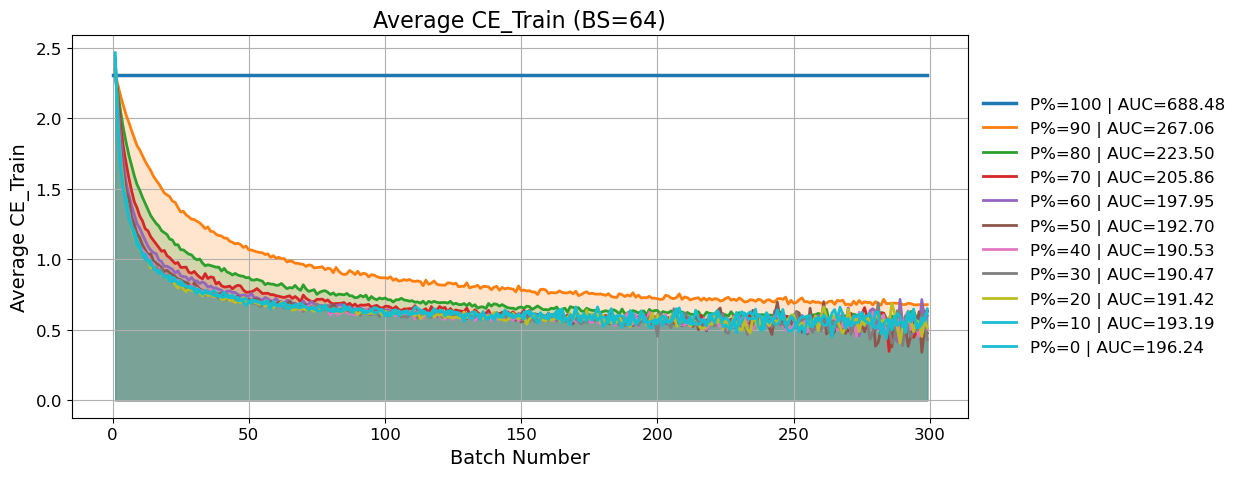

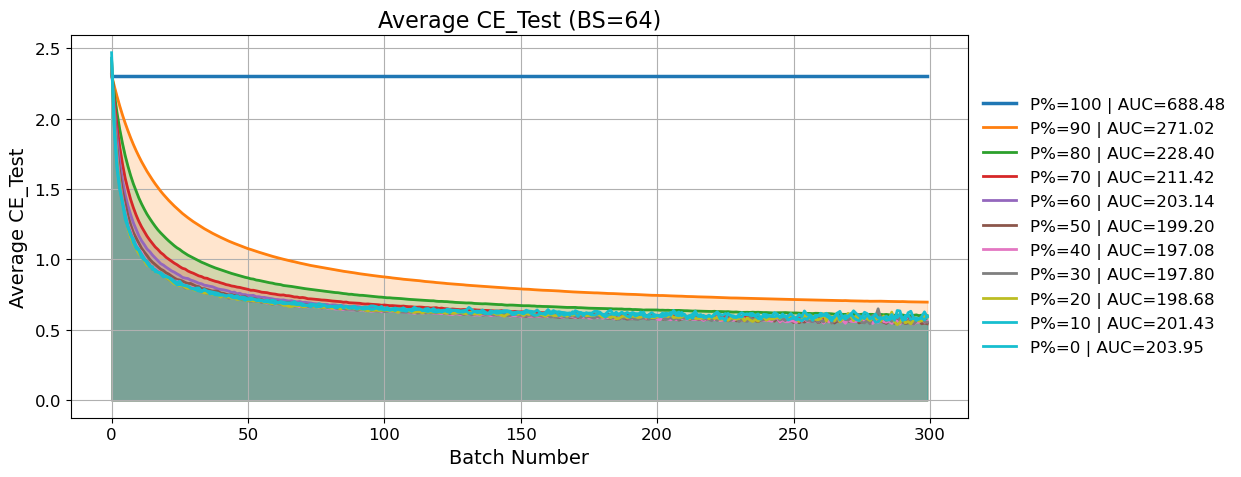

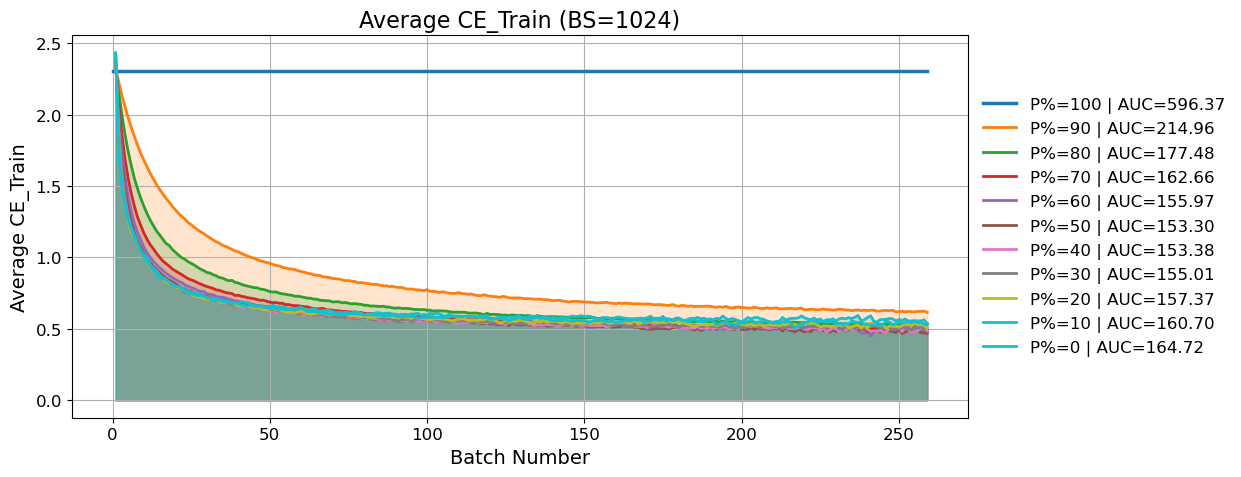

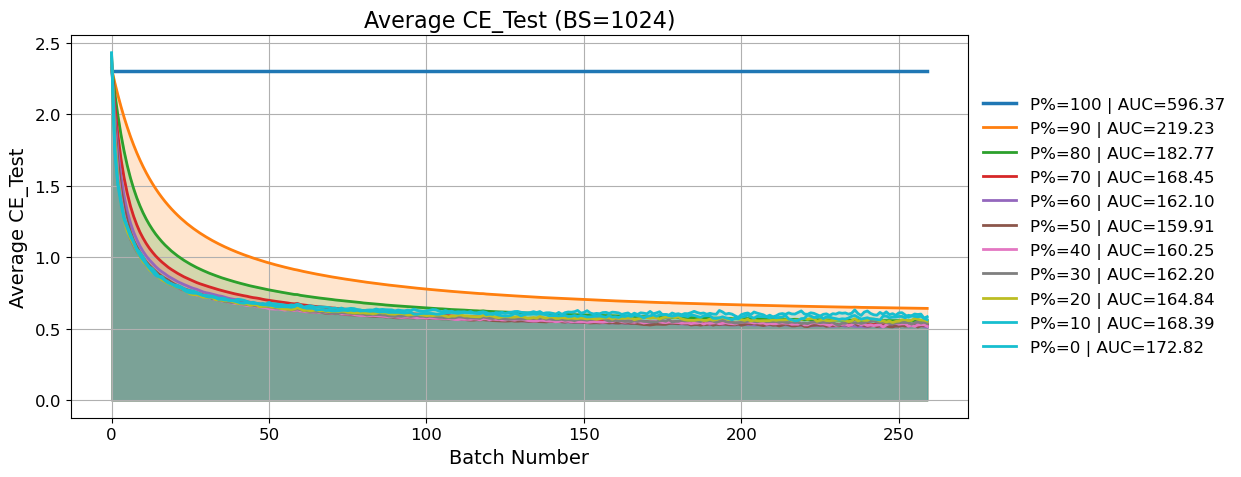

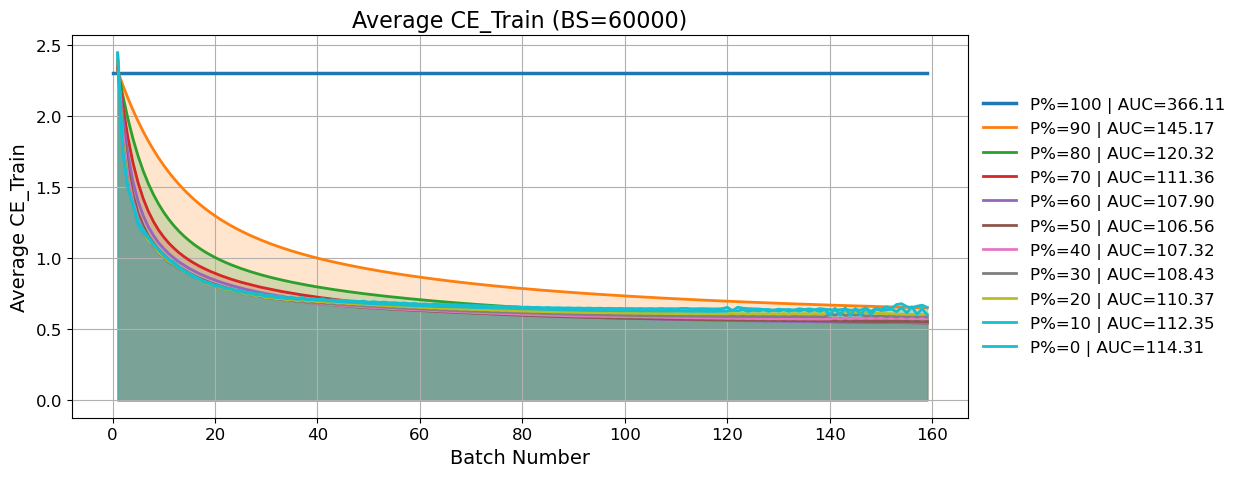

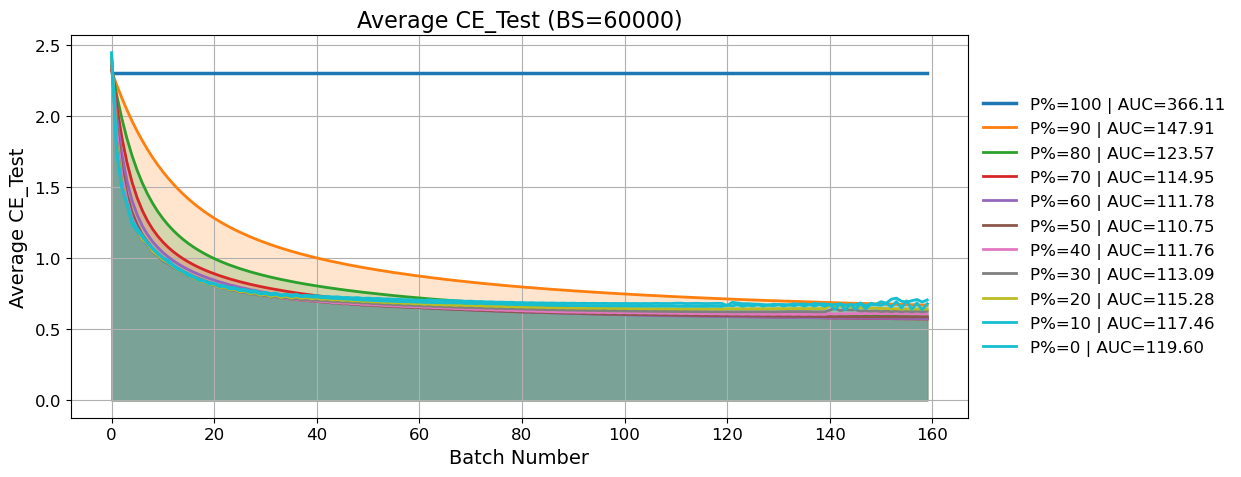

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"

BATCH_SIZES = [64, 1024, 60000]
PRUNING_PERCENTAGES = [round(x * 0.1, 1) for x in range(0, 11)]  # 0.0 to 1.0

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# =========================
# MAIN LOOP
# =========================
for bs in BATCH_SIZES:

    avg_dfs = {}

    # -------------------------
    # LOAD AVERAGED FILES
    # -------------------------
    for p in PRUNING_PERCENTAGES:
        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        file_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        if not os.path.isfile(file_path):
            print(f"[WARNING] File not found: {file_path}")
            continue

        df = pd.read_csv(file_path)
        avg_dfs[p] = df

    if not avg_dfs:
        print(f"No data found for batch size {bs}")
        continue

    # -------------------------
    # Find the lowest max Batch_Number across all pruning percentages EXCEPT 100%
    # -------------------------
    non100_dfs = {p: df for p, df in avg_dfs.items() if p != 1.0}
    if non100_dfs:
        lowest_max_batch = min(df["Batch_Number"].max() for df in non100_dfs.values())
    else:
        # fallback if only 100% exists
        lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

    # -------------------------
    # FUNCTION TO PLOT CE WITH AUC IN LEGEND
    # -------------------------
    def plot_ce(avg_dfs, bs, ce_column, title):
        plt.figure(figsize=(10, 5))
        plt.title(f"{title} (BS={bs})")
        plt.xlabel("Batch Number")
        plt.ylabel(title)

        colors = plt.get_cmap("tab10", len(avg_dfs))

        # Legend descending: 100% on top
        for i, p in enumerate(sorted(avg_dfs.keys(), reverse=True)):
            df = avg_dfs[p]

            if p == 1.0:
                # Flat line at last CE value, extend to lowest_max_batch
                ce_value = df[ce_column].iloc[-1]
                x_clean = np.array([0, lowest_max_batch])
                y_clean = np.array([ce_value, ce_value])
                auc = ce_value * lowest_max_batch
                plt.plot(x_clean, y_clean, color=colors(i),
                         linestyle='-', linewidth=2.5,
                         label=f"P%={int(p*100)} | AUC={auc:.2f}")
            else:
                # Normal pruning percentages (truncate to lowest_max_batch)
                df_trunc = df[df["Batch_Number"] <= lowest_max_batch]
                x = df_trunc["Batch_Number"].to_numpy()
                y = df_trunc[ce_column].to_numpy()

                # Remove NaNs
                mask = np.isfinite(x) & np.isfinite(y)
                x_clean = x[mask]
                y_clean = y[mask]

                if len(x_clean) == 0:
                    print(f"[WARNING] All NaN for P%={p} in {ce_column}")
                    continue

                auc = np.trapezoid(y_clean, x_clean)

                plt.plot(x_clean, y_clean, color=colors(i),
                         linestyle='-', linewidth=2.0,
                         label=f"P%={int(p*100)} | AUC={auc:.2f}")
                plt.fill_between(x_clean, y_clean, alpha=0.2, color=colors(i))

        plt.grid(True)
        plt.tight_layout()

        # Legend outside
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
        plt.show()

    # -------------------------
    # Plot CE_Train
    # -------------------------
    plot_ce(avg_dfs, bs, "Avg_CE_Train", "Average CE_Train")

    # -------------------------
    # Plot CE_Test
    # -------------------------
    plot_ce(avg_dfs, bs, "Avg_CE_Test", "Average CE_Test")


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG (SLP-FMNIST)
# =========================
BASE_DIR_ROOT = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"

BATCH_SIZES = [64, 1024, 60000]
PRUNING_PERCENTAGES = [round(x * 0.1, 1) for x in range(0, 11)]  # 0.0 → 1.0

# =========================
# OUTPUT DIRECTORIES
# =========================
AUC_GRAPH_DIR = os.path.join(BASE_DIR_ROOT, "AUC_graph")
AUC_DATA_DIR = os.path.join(BASE_DIR_ROOT, "AUC_data")
os.makedirs(AUC_GRAPH_DIR, exist_ok=True)
os.makedirs(AUC_DATA_DIR, exist_ok=True)
print(f"[INFO] Graphs → {AUC_GRAPH_DIR}")
print(f"[INFO] Data → {AUC_DATA_DIR}")

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Maximum CE cap
CE_MAX = np.log(10)  # ≈ 2.3026

# =========================
# DEFINE COLORS
# =========================
COLOR_LIST = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#800080",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#B9D9EB", "#17becf"
]

# =========================
# MAIN LOOP
# =========================
all_auc_records = []  # single list for both CE types

for bs in BATCH_SIZES:

    avg_dfs = {}

    # -------------------------
    # LOAD AVERAGED FILES
    # -------------------------
    for p in PRUNING_PERCENTAGES:
        folder = os.path.join(BASE_DIR_ROOT, BATCH_DIR_TEMPLATE.format(p, bs))
        file_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        if not os.path.isfile(file_path):
            print(f"[WARNING] File not found: {file_path}")
            continue

        df = pd.read_csv(file_path)
        # Cap CE values
        df["Avg_CE_Train"] = np.minimum(df["Avg_CE_Train"], CE_MAX)
        df["Avg_CE_Test"] = np.minimum(df["Avg_CE_Test"], CE_MAX)

        avg_dfs[p] = df

    if not avg_dfs:
        print(f"[WARNING] No data found for BS={bs}")
        continue

    # -------------------------
    # Find lowest max Batch_Number (exclude 100%)
    # -------------------------
    non100_dfs = {p: df for p, df in avg_dfs.items() if p != 1.0}
    if non100_dfs:
        lowest_max_batch = min(df["Batch_Number"].max() for df in non100_dfs.values())
    else:
        lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

    # -------------------------
    # PLOT FUNCTION
    # -------------------------
    def plot_and_save_ce(avg_dfs, bs, ce_column, title):

        plt.figure(figsize=(10, 5))
        plt.title(f"{title} (BS={bs})")
        plt.xlabel("Batch Number")
        plt.ylabel(title)

        for i, p in enumerate(sorted(avg_dfs.keys(), reverse=True)):
            df = avg_dfs[p]
            color = COLOR_LIST[i % len(COLOR_LIST)]

            if p == 1.0:
                ce_value = df[ce_column].iloc[-1]
                ce_value = min(ce_value, CE_MAX)
                x = np.array([0, lowest_max_batch])
                y = np.array([ce_value, ce_value])
                auc = ce_value * lowest_max_batch

                plt.plot(x, y, color=color, linewidth=2.5,
                         label=f"P%={int(p*100)} | AUC={auc:.2f}")

            else:
                df_trunc = df[df["Batch_Number"] <= lowest_max_batch]
                x = df_trunc["Batch_Number"].to_numpy()
                y = np.minimum(df_trunc[ce_column].to_numpy(), CE_MAX)  # cap CE

                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]

                if len(x) == 0:
                    print(f"[WARNING] NaNs only for P%={p}, BS={bs}")
                    continue

                auc = np.trapezoid(y, x)

                plt.plot(x, y, color=color, linewidth=2.0,
                         label=f"P%={int(p*100)} | AUC={auc:.2f}")
                plt.fill_between(x, y, alpha=0.2, color=color)

            # Append to global records (single CSV)
            all_auc_records.append([bs, p, ce_column, auc])

        plt.grid(True)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
        plt.tight_layout()

        # SAVE FIGURE
        fig_path = os.path.join(AUC_GRAPH_DIR, f"{ce_column}_BS_{bs}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"[SAVED] {fig_path}")

    # -------------------------
    # Plot Train & Test
    # -------------------------
    plot_and_save_ce(avg_dfs, bs, "Avg_CE_Train", "Average CE Train")
    plot_and_save_ce(avg_dfs, bs, "Avg_CE_Test", "Average CE Test")

# -------------------------
# SAVE SINGLE CSV FOR ALL
# -------------------------
if all_auc_records:
    auc_df = pd.DataFrame(all_auc_records, columns=["Batch_Size", "Pruning_Percentage", "CE_Type", "AUC"])
    csv_path = os.path.join(AUC_DATA_DIR, "AUC_ALL_BS.csv")
    auc_df.to_csv(csv_path, index=False)
    print(f"[SAVED] {csv_path}")

print("\n✅ All AUC graphs and combined data saved successfully.")


[INFO] Graphs → C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph
[INFO] Data → C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_data
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_64.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_64.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_1024.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_1024.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_60000.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_60000.png
[SAVED] C:\Users\Student\Desktop\Neural_research\p

In [2]:
print("SCRIPT STARTED")
print("BASE_DIR:", BASE_DIR)
print("BASE_DIR exists:", os.path.exists(BASE_DIR))

OUTPUT_DIR = os.path.join(BASE_DIR, "AUC_RESULTS")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)
print("OUTPUT_DIR exists:", os.path.exists(OUTPUT_DIR))


SCRIPT STARTED
BASE_DIR: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL
BASE_DIR exists: True
OUTPUT_DIR: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_RESULTS
OUTPUT_DIR exists: True


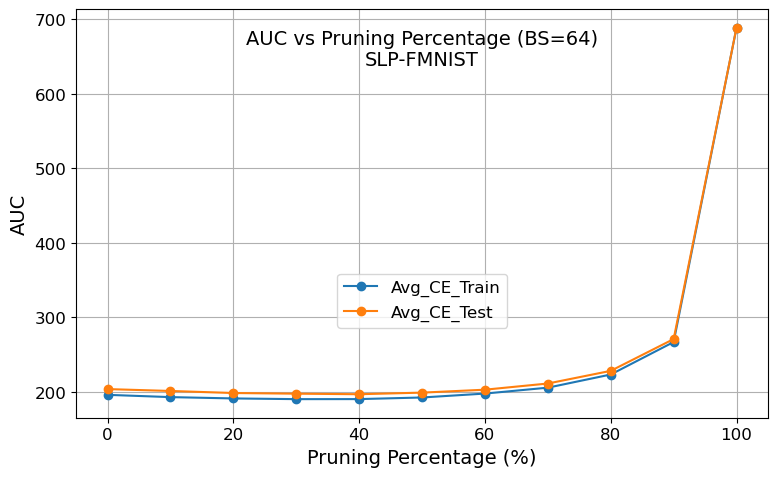

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_PLOTS\AUC_vs_Prune_BS_64.png


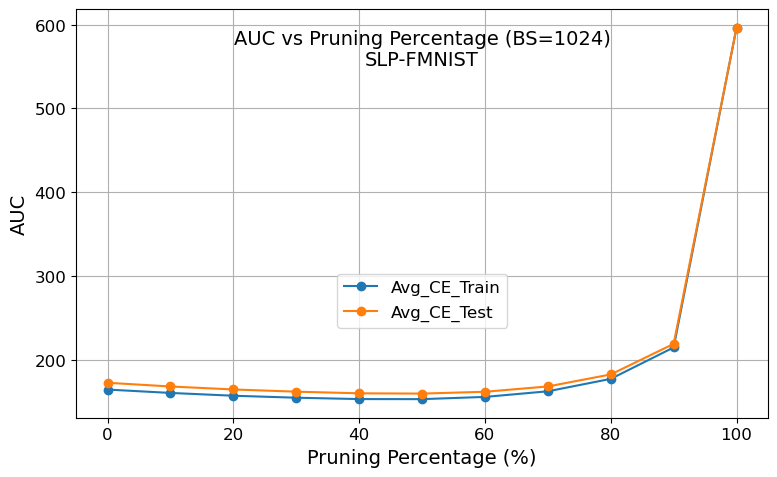

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_PLOTS\AUC_vs_Prune_BS_1024.png


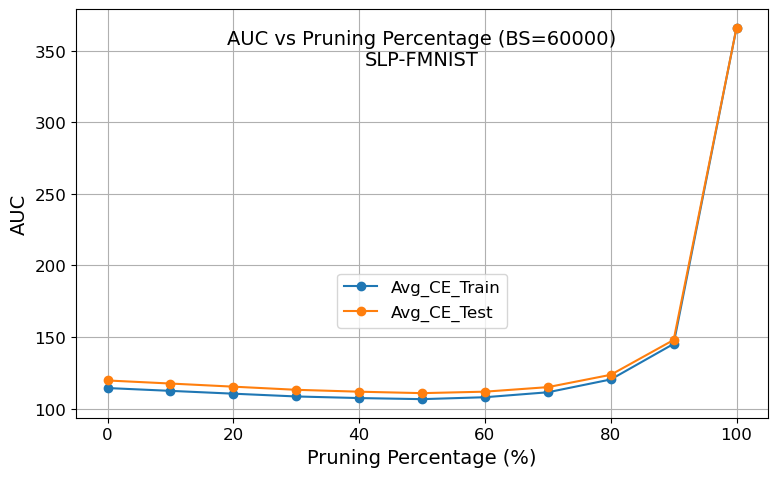

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL\AUC_PLOTS\AUC_vs_Prune_BS_60000.png

✅ All AUC vs Pruning Percentage plots generated.


In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"
AUC_DIR = os.path.join(BASE_DIR, "AUC_RESULTS")  # where your CSVs are
OUTPUT_PLOT_DIR = os.path.join(BASE_DIR, "AUC_PLOTS")
os.makedirs(OUTPUT_PLOT_DIR, exist_ok=True)

BATCH_SIZES = [64, 1024, 60000]
METRICS = ["Avg_CE_Train", "Avg_CE_Test"]

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# =========================
# LOOP OVER BATCH SIZES & METRICS
# =========================
for bs in BATCH_SIZES:
    plt.figure(figsize=(8,5))
    plt.text(0.50, 0.95, f"AUC vs Pruning Percentage (BS={bs})",
             transform=plt.gca().transAxes, va="top", ha="center")
    plt.text(0.50, 0.90, "SLP-FMNIST",
             transform=plt.gca().transAxes, va="top", ha="center")
    # plt.title(f"")
    plt.xlabel("Pruning Percentage (%)")
    plt.ylabel("AUC")
    
    for metric in METRICS:
        # Load the CSV
        csv_file = os.path.join(AUC_DIR, f"AUC_{metric}_BS_{bs}.csv")
        if not os.path.isfile(csv_file):
            print(f"[WARNING] CSV not found: {csv_file}")
            continue
        
        df = pd.read_csv(csv_file)
        
        # Sort by pruning percentage
        df = df.sort_values("Pruning_Percentage")
        
        # Convert pruning to percentage for X-axis
        x = df["Pruning_Percentage"] * 100
        y = df["AUC"]
        
        plt.plot(x, y, marker='o', label=metric)
    
    plt.grid(True)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 0.2))

    # plt.ylim(150,300)
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(OUTPUT_PLOT_DIR, f"AUC_vs_Prune_BS_{bs}.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    
    print(f"[SAVED] {plot_path}")

print("\n✅ All AUC vs Pruning Percentage plots generated.")
